In [ ]:
import json
from typing import cast
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from torch.utils.data import DataLoader, Subset

from network.dataclass import LunarLanderDataset
from network.model import LunarLanderConv

In [4]:
OUTPUT_PATH = Path("..") / "output" / "threshold_200.0_dropout0.1" / "20260525_210913"

In [5]:
with open (OUTPUT_PATH / "history.json", "r") as f:
    history = json.load(f)

In [6]:
train_epochs =[a[0] for a in history["train_history"]]
train_loss = [a[1] for a in history["train_history"]]
val_history = [a[1] for a in history["val_history"]]
val_epochs = [a[0] for a in history["val_history"]]

In [8]:
train_hist = pd.DataFrame({"epoch": train_epochs, "loss": train_loss})
val_hist = pd.DataFrame({"epoch": val_epochs, "val_loss": val_history})

In [9]:
loss_df = train_hist.merge(val_hist, on = "epoch")

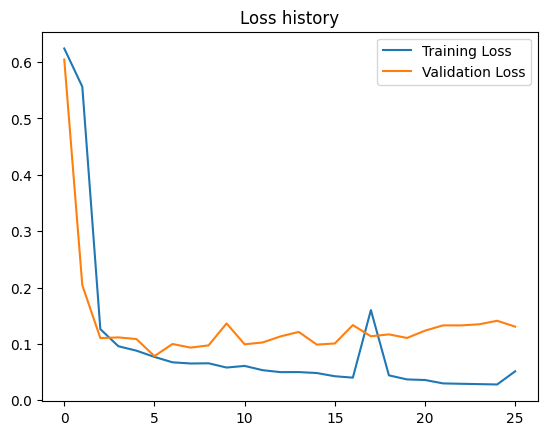

In [10]:
loss_df.loss.plot()
loss_df.val_loss.plot()
plt.legend(["Training Loss", "Validation Loss"])
plt.title("Loss history")

plt.show()

In [11]:
state_dict = torch.load(OUTPUT_PATH / "best_model.pt")
model = LunarLanderConv(dropout_rate=0.1)
model.load_state_dict(state_dict)
dataset = LunarLanderDataset("../data/preprocessed.h5")
test_indices = torch.load(OUTPUT_PATH / "test_indices.pt")
test_ds = Subset(dataset, test_indices)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False)

In [13]:
model.eval()
all_logits = []
all_actuals = []
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
with torch.no_grad():
    for batch in test_loader:
        frames: torch.Tensor
        lengths: torch.Tensor
        rewards: torch.Tensor
        frames, lengths, rewards = batch
        frames = frames.to(device)
        lengths = lengths.to(device)
        out = cast(torch.Tensor, model(frames, lengths))
        all_logits.append(out.squeeze().cpu().numpy())
        all_actuals.append(rewards.cpu().numpy())

logits = np.concatenate(all_logits).reshape(-1, 1)
actuals = np.concatenate(all_actuals).reshape(-1, 1)

In [25]:
preds = (logits >= 0).astype(float)
target = (actuals >=200).astype(float)

In [26]:
print(classification_report(target, preds))

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98        87
         1.0       0.99      0.99      0.99       183

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



In [27]:
print(confusion_matrix(target, preds))

[[ 85   2]
 [  1 182]]


In [29]:
print(roc_auc_score(target, logits))

0.994472709000691


In [ ]:
correct = (target == preds)
results = pd.DataFrame({"index": test_indices, "correct": correct.squeeze()})

In [37]:
results[~results.correct]

,index,correct
126,48,False
131,1737,False
207,1754,False


In [38]:
result_df = pd.read_csv("/home/ec2-user/landing-vision/videos/lunar_lander/20260521_151828/256_256/episode_rewards.csv")

In [48]:
from preprocessing.video_process import get_joined_df

In [49]:
df = get_joined_df(
    rewards_df=result_df,
    video_dir=Path("..") / "videos" / "lunar_lander" / "20260521_151828" / "256_256",
    episode_col = "Episode"
)

In [51]:
df.iloc[48]

Episode                                800
Episode_Reward                   -8.924717
filename          rl-video-episode-800.mp4
Name: 48, dtype: object

In [52]:
df.iloc[1737]

Episode                                28950
Episode_Reward                    286.251794
filename          rl-video-episode-28950.mp4
Name: 1737, dtype: object

In [53]:
df.iloc[1754]

Episode                                29202
Episode_Reward                    -17.974307
filename          rl-video-episode-29202.mp4
Name: 1754, dtype: object